Initial steps to understanding this topic

In [35]:
# importing libraries
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
np.random.normal(5, 2)



5.406412864586132

### Building the OU process - 2023 paper

$$ d X_t dt = - X_t dt + \sqrt{2} dB_t , \quad X_0 \sim \pi_D $$

This is the same as the following:
$X_t = m_t X_0 + \sigma_t Z_t$ where $ m_t = e^{-t}$ and $\sigma_t^2 = 1- e^{-2t}$.

$$X_t \rightarrow \mathcal{N}(0,I)$$
 

## Building most basic python setup. 
- Forward process, need to be able to sample from $X_t|X_0$. Use this to generate training data for the score estimator. 
Choose $d=2$ and need to choose T.
- SGDL optimisation. Define the loss function score matching objective rewritten via denoising score matching $$U(\theta) = \mathbb{E}[\kappa (\tau) | \sigma_\tau^{-1}Z + s(\tau, \theta, m_\tau X_0 + \sigma_\tau Z)|^2] + C$$
Use the SGLD algo
$$ \theta_0^\lambda := \theta_0, \quad \theta_{n+1}^\lambda = \theta_n^\lambda - \lambda H(\theta_n^\lambda, \mathbf{X}_{n+1}) + \sqrt{2\lambda/\beta} \, \xi_{n+1}, \quad n \in \mathbb{N}_0$$

Use function for stochastic gradient descent: 
$$ H(\theta, \bold{x}) = 2 \sigma_t^2  m_t  (\sigma_t^{-1} z - m_t x_0 - \sigma_t z + m_t \theta) $$

In [ ]:
# Generating samples from the 'unknown mean - known sigma' distribuition we want to estimate the score.
# We want to be able to understand pi_D

np.random.seed(1)

d = 2           #set the dimension as 2 for now
sigma2_known = 1

mu_unknown = np.random.uniform(0, 1, d)
print(f'mu of the data we want to understand = {mu_unknown}')

# sample of Data we are trying to understand.
X_0 = np.random.normal(mu_unknown, sigma2_known, d)



# gamma = 0.01    # time step, ie delta t
t_0 = 0         # initial time
T = 1           # final time

# numsteps = (T - t_0)/gamma
numsteps = 101

times = np.linspace(t_0, T, numsteps)


# Generating gaussian noise to perturb the data with for visualising.
Z = []
m = np.exp(-times)              # mu calculation solved from the solution to the ODE
sigma2 = 1 - np.exp(-2*times)   #variance calculation from ode solution
X= []

# loop over all time indices
for i in range(len(times)):
    # generate the standard normal noise of dimension d matching the data
    Z_t = np.random.normal(0, 1, d)
    Z.append(Z_t)


    X_t = m[i] * X_0 + np.sqrt(sigma2[i]) * Z_t
    X.append(X_t)


X = np.array(X)

print(f'X_0  = {X_0}')


mu of the data we want to understand = [0.417022   0.72032449]
X_0  = [-0.11114975 -0.35264413]


Text(0.5, 0, 't: Time periods')

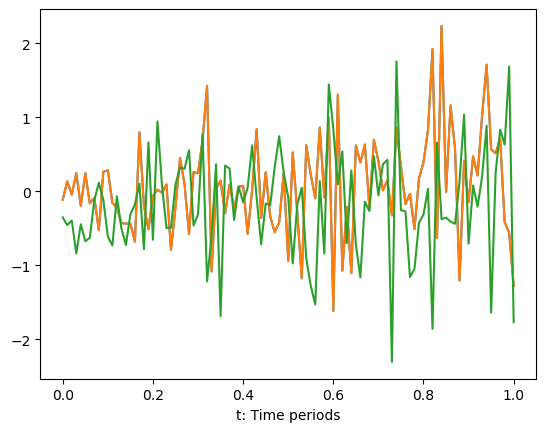

In [ ]:
# print(t)
plt.plot(times, X[:, 0])
plt.plot(times, X)
plt.xlabel('t: Time periods')


In [75]:
# Trying to do the SGDL (Langevin dynamics)
d = 2
kappa = sigma2      # Set this to be the same as the
lambda_ = (T- t_0)/ numsteps

theta_0 = np.zeros(d)     # initialise this value. The paper seems not to have much on this. going to try 0
# Euler numerical scheme. Fix beta
beta = 1e12

# H(theta, x) expands to H(theta, t, X_0, z). z is of dimension d. 
def H_func(theta, X):
    tau, X_0, z = X

    m_tau = np.exp(-tau)
    sigma2_tau = 1 - np.exp(-2 * tau)
    sigma_tau = np.sqrt(sigma2_tau)

    return 2 * sigma2_tau * m_tau * ((1/sigma_tau) * z - m_tau * X_0 - sigma_tau * z + m_tau * theta)


def theta_nplusone_func(lambda_, beta,  theta_n, X):

    return theta_n - lambda_ * H_func(theta = theta_n, X= X) + (np.sqrt(2* lambda_ / beta) * np.random.normal(0, 1, len(theta_n)))



def thetahat_func(d, mu_unknown, sigma_known, beta, lambda_, theta_0, N_sgld, t_0, T):

    ''' 
    SGLD for theta
    '''
    # initialise theta
    theta = theta_0
    theta_tracker = [theta_0]

    for i in range(N_sgld):
    # draw fresh sample
        tau = np.random.uniform(t_0, T)
        x0_n = np.random.normal(mu_unknown, sigma_known, d)
        z_n = np.random.normal(0, 1, d)
        X_n = (tau, x0_n, z_n)

        # update theta
        theta = theta_nplusone_func(lambda_ = lambda_, beta = beta, theta_n = theta, X = X_n)

        theta_tracker.append(theta)



    return theta, theta_tracker




In [95]:
# Trying to get this stochastic gradient descent algo to function.
d = 2
mu_unknown = np.array([0.7, -0.41])
sigma_known = np.array([1,1])
theta_0 = np.zeros(d)
beta = 1e12
lambda_ = 0.05
N_sgld = 400
t_0 = 0
T = 1

theta_hat, theta_tracker = thetahat_func(d = d, mu_unknown= mu_unknown, sigma_known=sigma_known, beta= beta, lambda_= lambda_, 
                          theta_0= theta_0, N_sgld= N_sgld, t_0= t_0, T = T )



[ 0.49537653 -0.54556646]


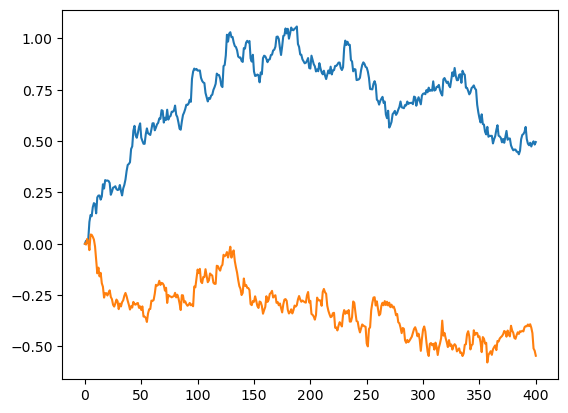

In [96]:
print(theta_hat)
plt.plot(theta_tracker)

Can clearly see that both converge towards the parametrized (unknown by the model) mean